In [1]:
# -*- coding: utf-8 -*-
# Regression Example With Boston Dataset: Standardized and Wider
from pandas import read_csv
from keras.models import Sequential
from keras.layers import Dense
from keras.wrappers.scikit_learn import KerasRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from tensorflow.keras import layers
from sklearn.utils import shuffle

import pandas as pd
import seaborn as sns
import keras
import keras.utils
import tensorflow as tf
from matplotlib import pyplot as plt
import numpy as np


from cgi import test



,Time,Voltage,Days Elapsed,Sensor Number,Rising Edge,Starting Edge,End Measurement,pH
13886,17,0.009703,141,2,0,1,0,7
8823,20,-0.001828,105,1,0,1,0,7
16190,3,0.097924,114,2,1,0,0,3
10071,43,0.170581,114,2,0,0,1,3
7059,16,-0.001547,114,1,0,1,0,7
...,...,...,...,...,...,...,...,...
4741,29,-0.092673,141,2,0,1,0,10
717,43,0.005766,107,2,0,0,1,7
2545,50,0.001359,141,2,0,0,1,7
4713,28,-0.129518,114,1,0,1,0,10


,Time,Voltage,Days Elapsed,Sensor Number,Rising Edge,Starting Edge,End Measurement
0,-0.521302,1.607284,0.853769,0.738192,-0.497126,1.220067,-0.816497
1,0.033004,-1.302085,-0.798167,-1.354661,-0.497126,1.220067,-0.816497
2,1.488056,0.027217,-0.798167,-1.354661,-0.497126,-0.819627,1.224745
3,0.379445,1.543942,0.985924,0.738192,-0.497126,-0.819627,1.224745
4,-0.937031,0.117459,-0.798167,0.738192,-0.497126,1.220067,-0.816497
...,...,...,...,...,...,...,...
13595,-1.422049,0.004657,-1.392863,-1.354661,2.011562,-0.819627,-0.816497
13596,1.003038,0.100105,-1.392863,-1.354661,-0.497126,-0.819627,1.224745
13597,1.557344,1.474526,-1.260709,-1.354661,-0.497126,-0.819627,1.224745
13598,-0.867743,0.123533,-0.798167,0.738192,-0.497126,1.220067,-0.816497


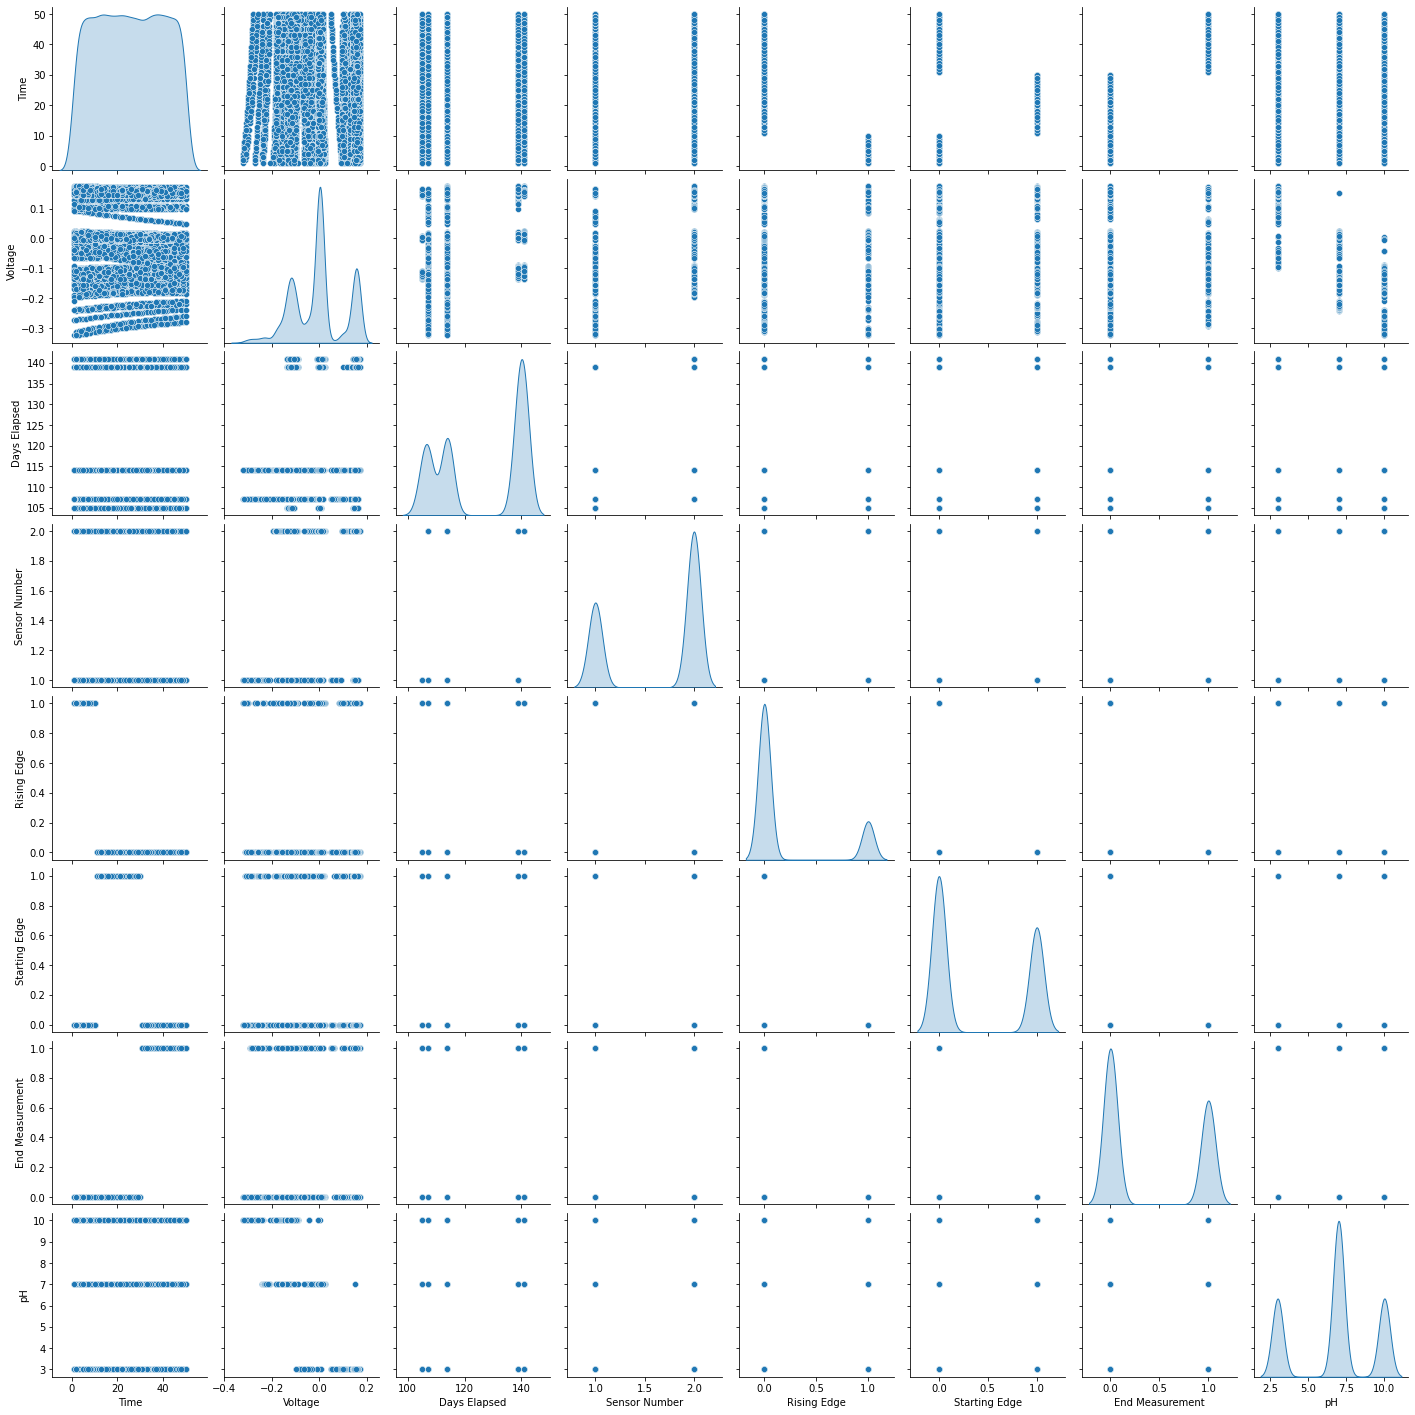

In [2]:
dataset = pd.read_csv('organized_ph_data_2.csv')


dataset = shuffle(dataset)

display(dataset)
std_scaler = StandardScaler()


train_dataset = dataset.sample(frac=0.8, random_state=3)
test_dataset = dataset.drop(train_dataset.index)


train_features = train_dataset.copy()
test_features = test_dataset.copy()


train_labels = train_features.pop('pH')
test_labels = test_features.pop('pH')

train_features = std_scaler.fit_transform(train_features.to_numpy())
dict2 = {'Time':train_features[:, 0],'Voltage':train_features[:, 1], 'Days Elapsed':train_features[:, 2] ,'Sensor Number':train_features[:, 3], 'Rising Edge':train_features[:, 4], 'Starting Edge':train_features[:, 5], 'End Measurement':train_features[:, 6]}
train_features = pd.DataFrame(dict2)
display(train_features)


test_features = std_scaler.fit_transform(test_features.to_numpy())
dict2 = {'Time':test_features[:, 0],'Voltage':test_features[:, 1], 'Days Elapsed':test_features[:, 2] ,'Sensor Number':test_features[:, 3], 'Rising Edge':test_features[:, 4], 'Starting Edge':test_features[:, 5], 'End Measurement':test_features[:, 6]}
test_features = pd.DataFrame(dict2)


sns.pairplot(train_dataset[['Time','Voltage', 'Days Elapsed', 'Sensor Number', 'Rising Edge', 'Starting Edge', 'End Measurement', 'pH']], diag_kind='kde')






In [12]:
#Iterate through this a few dozen times

def build_model(n1, n2):
  #Experiment with different models, thicknesses, layers, activation functions; Don't limit to only 10 nodes; Measure up to 64 nodes in 2 layers
  model = keras.Sequential([
    layers.Dense(n1, activation=tf.nn.relu, input_shape=[len(train_features.keys())]),
    layers.Dense(n2, activation=tf.nn.relu),
    layers.Dense(1)
  ])

  optimizer = tf.keras.optimizers.RMSprop(0.001)
  model.compile(loss='mse', optimizer=optimizer, metrics=['mae','mse'])
  #Prepares model for training. Can use an optimizer
  #Change the different
  #model.compile(loss='mse', optimizer=optimizer, metrics=['mae','mse'])
  #adam optimizer performs gradient descent


  early_stop = keras.callbacks.EarlyStopping(monitor='val_loss',patience=5)

  return model

def model_history(features, labels, model, epo, batch, vbs):
  
    history = model.fit(
        features, labels,
        epochs=epo, batch_size=batch, validation_split=0.2, verbose=vbs #, callbacks=early_stop
    )

    hist = pd.DataFrame(history.history)
    
    return hist



In [13]:


def plot_loss(history):

  plt.plot(history['loss'], label='loss')
  plt.plot(history['val_loss'], label='val_loss')
  plt.xlabel('Epoch')
  plt.ylabel('Error')
  plt.legend()
  plt.grid(True)
  plt.show()

def correlation_plots(model, label, input_data, title, xlabel, ylabel):
#test_loss, test_acc = model.evaluate(test_features, test_labels, verbose = 1)

  test_predictions = model.predict(input_data).flatten()
  plt.scatter(label,test_predictions)
  plt.xlabel(xlabel)
  plt.ylabel(ylabel)
  plt.title(title)
  plt.axis('equal')
  plt.axis('square')
  plt.grid(True)
  plt.show()
  return test_predictions


def plotGraph(y_test, y_pred,regressorName):
    plt.scatter(range(len(y_pred)), y_test, color='blue')
    plt.scatter(range(len(y_pred)), y_pred, color='red')
    plt.title(regressorName)
    plt.show()
    return




first hidden layer 32
second hidden layer 32
processing fold # 0
107/107 [==============================] - 0s 1ms/step - loss: 0.8108 - mae: 0.5089 - mse: 0.8108


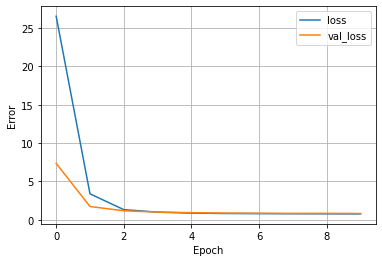

processing fold # 1
107/107 [==============================] - 0s 1ms/step - loss: 0.7547 - mae: 0.5236 - mse: 0.7547


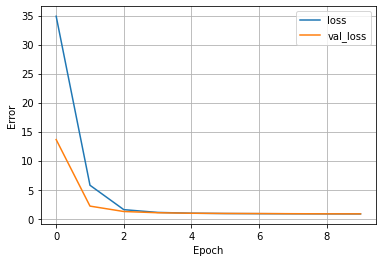

processing fold # 2
107/107 [==============================] - 0s 1ms/step - loss: 0.8258 - mae: 0.5120 - mse: 0.8258


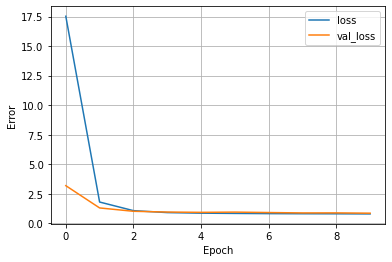

processing fold # 3
107/107 [==============================] - 0s 1ms/step - loss: 0.7957 - mae: 0.4869 - mse: 0.7957


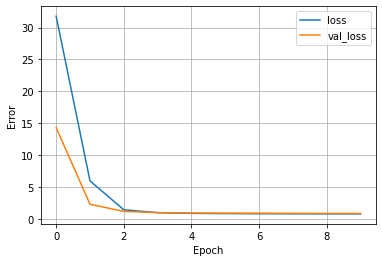

107/107 [==============================] - 0s 951us/step


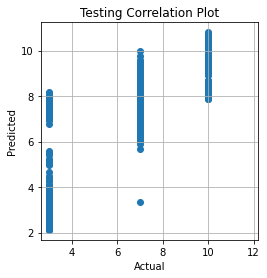

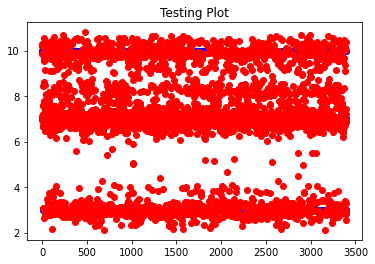

425/425 [==============================] - 0s 1ms/step


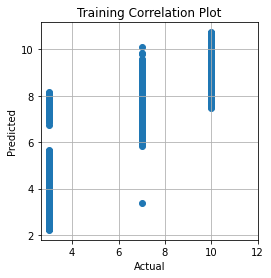

first hidden layer 32
second hidden layer 33
processing fold # 0
107/107 [==============================] - 0s 1ms/step - loss: 0.8177 - mae: 0.5007 - mse: 0.8177


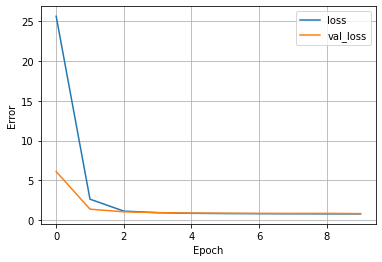

processing fold # 1
107/107 [==============================] - 0s 1ms/step - loss: 0.7589 - mae: 0.5202 - mse: 0.7589


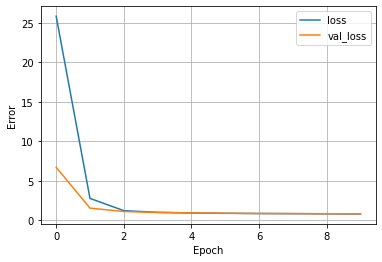

processing fold # 2
107/107 [==============================] - 0s 1ms/step - loss: 0.8175 - mae: 0.5069 - mse: 0.8175


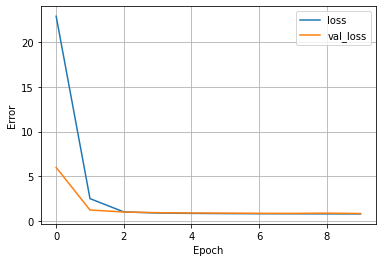

processing fold # 3
107/107 [==============================] - 0s 1ms/step - loss: 0.8166 - mae: 0.4997 - mse: 0.8166


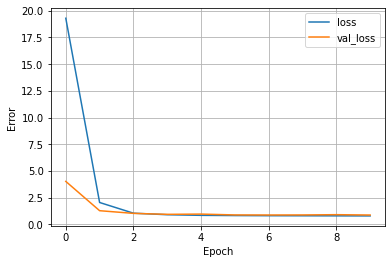

107/107 [==============================] - 0s 968us/step


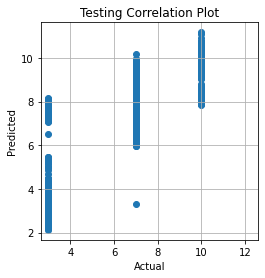

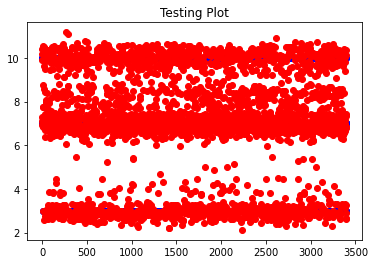

425/425 [==============================] - 0s 1ms/step


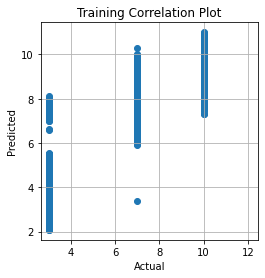

first hidden layer 32
second hidden layer 34
processing fold # 0
107/107 [==============================] - 0s 1ms/step - loss: 0.8269 - mae: 0.4878 - mse: 0.8269


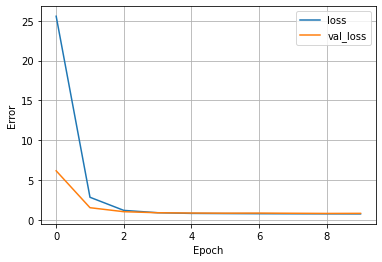

processing fold # 1
107/107 [==============================] - 0s 1ms/step - loss: 0.7728 - mae: 0.5353 - mse: 0.7728


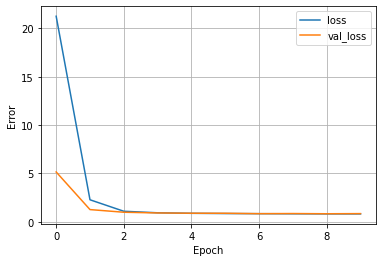

processing fold # 2
107/107 [==============================] - 0s 1ms/step - loss: 0.8240 - mae: 0.4741 - mse: 0.8240


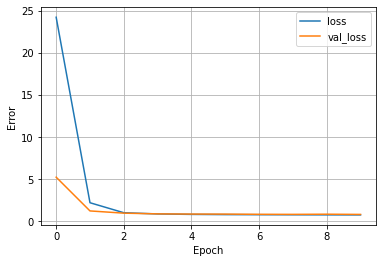

processing fold # 3
107/107 [==============================] - 0s 1ms/step - loss: 0.8001 - mae: 0.5135 - mse: 0.8001


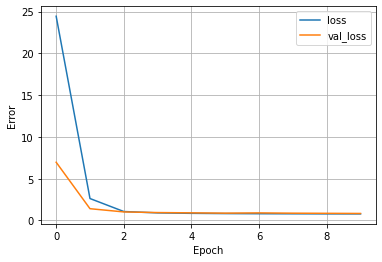

107/107 [==============================] - 0s 1ms/step


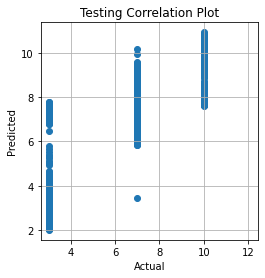

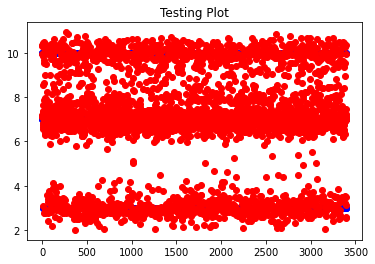

425/425 [==============================] - 0s 997us/step


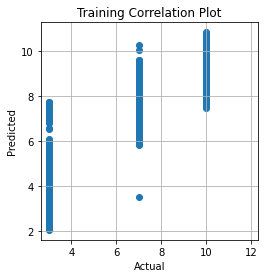

first hidden layer 32
second hidden layer 35
processing fold # 0
107/107 [==============================] - 0s 1ms/step - loss: 0.8115 - mae: 0.5124 - mse: 0.8115


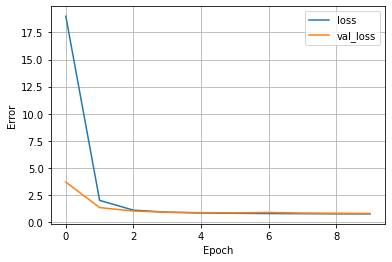

processing fold # 1
107/107 [==============================] - 0s 1ms/step - loss: 0.7542 - mae: 0.5130 - mse: 0.7542


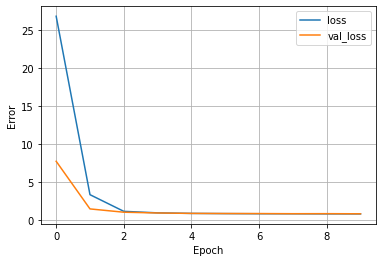

processing fold # 2
107/107 [==============================] - 0s 1ms/step - loss: 0.8137 - mae: 0.4942 - mse: 0.8137


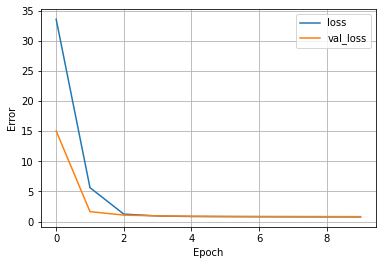

processing fold # 3
107/107 [==============================] - 0s 1ms/step - loss: 0.8210 - mae: 0.5118 - mse: 0.8210


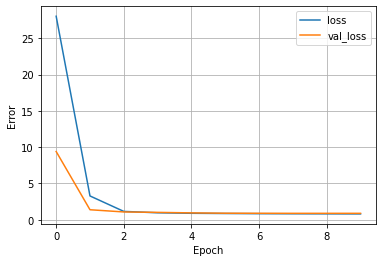

107/107 [==============================] - 0s 906us/step


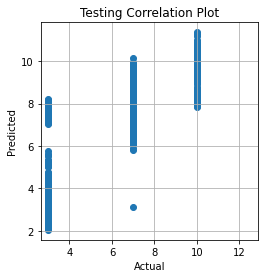

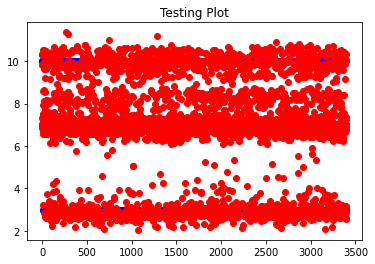

425/425 [==============================] - 1s 1ms/step


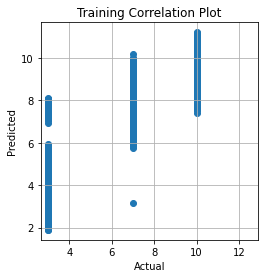

first hidden layer 32
second hidden layer 36
processing fold # 0
107/107 [==============================] - 0s 1ms/step - loss: 0.8278 - mae: 0.5523 - mse: 0.8278


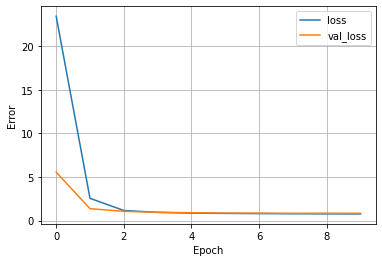

processing fold # 1
107/107 [==============================] - 0s 1ms/step - loss: 0.7545 - mae: 0.5192 - mse: 0.7545


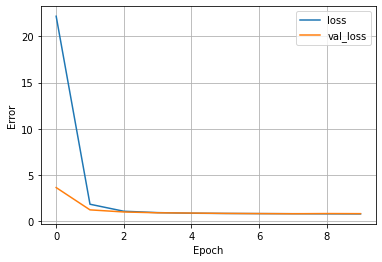

processing fold # 2
107/107 [==============================] - 0s 1ms/step - loss: 0.8220 - mae: 0.5202 - mse: 0.8220


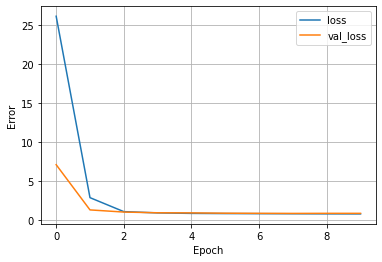

processing fold # 3
107/107 [==============================] - 0s 1ms/step - loss: 0.8102 - mae: 0.5274 - mse: 0.8102


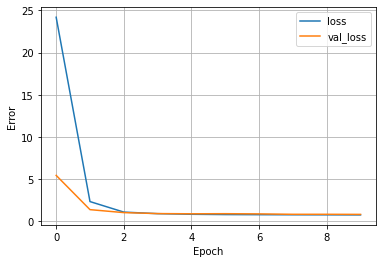

107/107 [==============================] - 0s 1ms/step


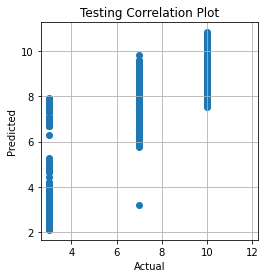

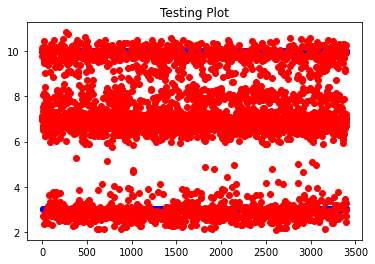

425/425 [==============================] - 0s 993us/step


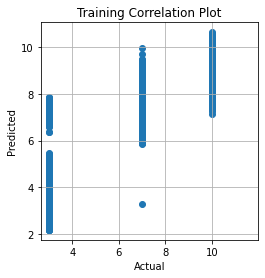

first hidden layer 32
second hidden layer 37
processing fold # 0
107/107 [==============================] - 0s 1ms/step - loss: 0.8299 - mae: 0.5138 - mse: 0.8299


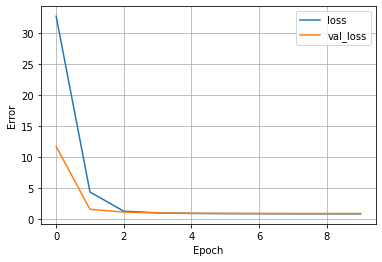

processing fold # 1
107/107 [==============================] - 0s 1ms/step - loss: 0.7517 - mae: 0.5119 - mse: 0.7517


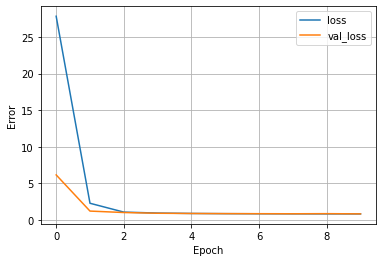

processing fold # 2
107/107 [==============================] - 0s 1ms/step - loss: 0.8257 - mae: 0.5241 - mse: 0.8257


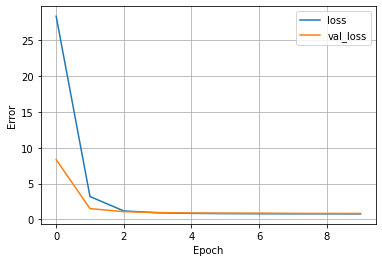

processing fold # 3
107/107 [==============================] - 0s 1ms/step - loss: 0.8285 - mae: 0.5460 - mse: 0.8285


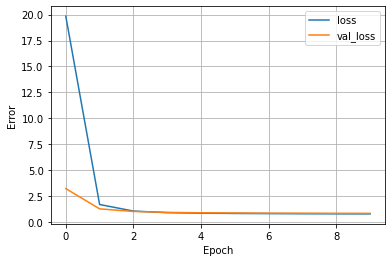

107/107 [==============================] - 0s 1ms/step


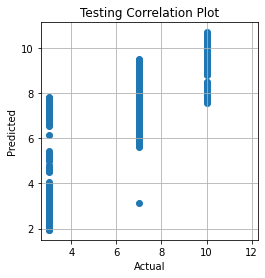

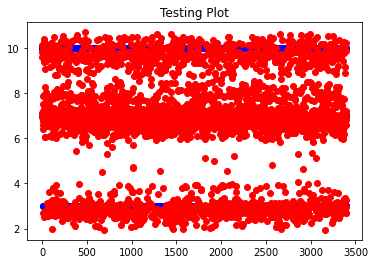

425/425 [==============================] - 0s 980us/step


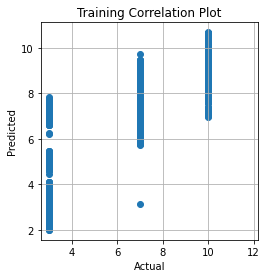

first hidden layer 32
second hidden layer 38
processing fold # 0
107/107 [==============================] - 0s 1ms/step - loss: 0.8135 - mae: 0.4991 - mse: 0.8135


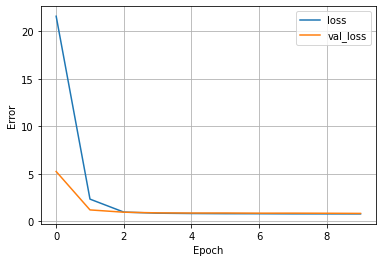

processing fold # 1
107/107 [==============================] - 0s 1ms/step - loss: 0.7357 - mae: 0.5023 - mse: 0.7357


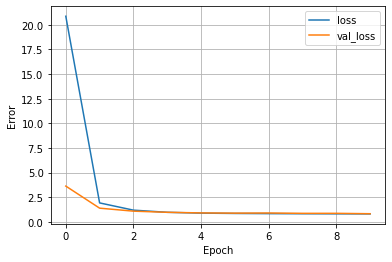

processing fold # 2
107/107 [==============================] - 0s 1ms/step - loss: 0.8094 - mae: 0.5369 - mse: 0.8094


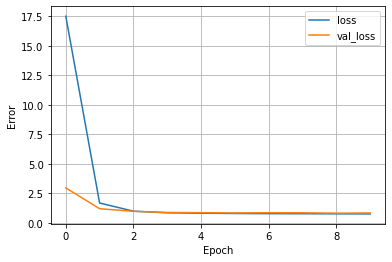

processing fold # 3
107/107 [==============================] - 0s 1ms/step - loss: 0.8225 - mae: 0.5473 - mse: 0.8225


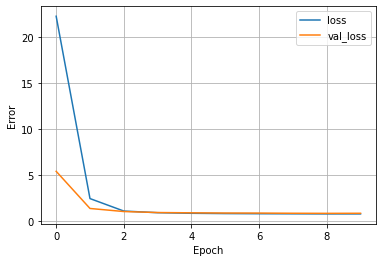

107/107 [==============================] - 0s 981us/step


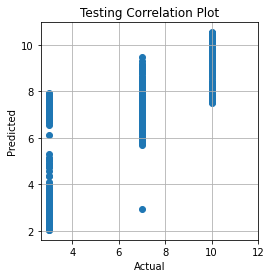

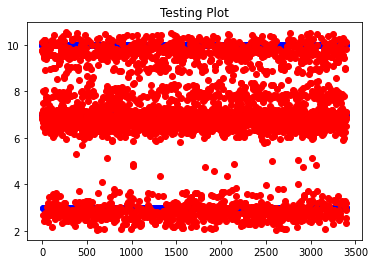

425/425 [==============================] - 0s 1ms/step


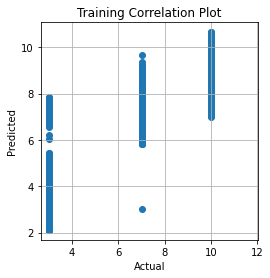

first hidden layer 33
second hidden layer 32
processing fold # 0
107/107 [==============================] - 0s 1ms/step - loss: 0.8300 - mae: 0.5359 - mse: 0.8300


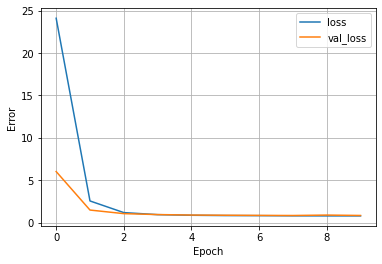

processing fold # 1
107/107 [==============================] - 0s 1ms/step - loss: 0.7350 - mae: 0.4821 - mse: 0.7350


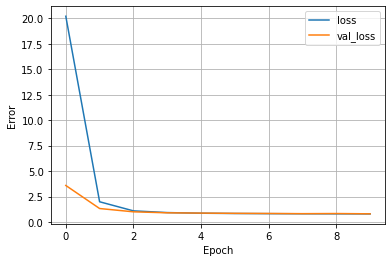

processing fold # 2
107/107 [==============================] - 0s 1ms/step - loss: 0.8294 - mae: 0.4903 - mse: 0.8294


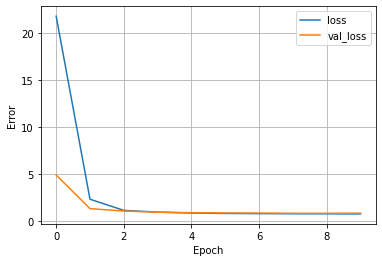

processing fold # 3
107/107 [==============================] - 0s 1ms/step - loss: 0.7805 - mae: 0.5014 - mse: 0.7805


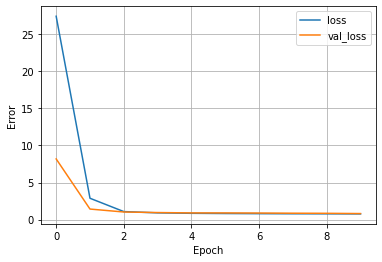

107/107 [==============================] - 0s 988us/step


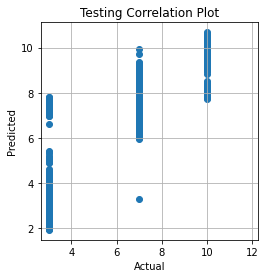

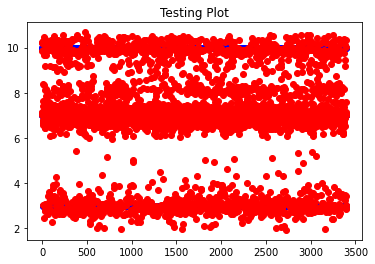

425/425 [==============================] - 0s 990us/step


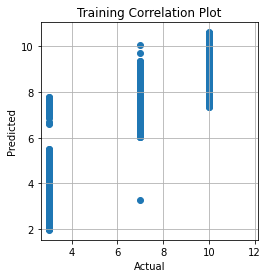

first hidden layer 33
second hidden layer 33
processing fold # 0
107/107 [==============================] - 0s 1ms/step - loss: 0.8421 - mae: 0.5341 - mse: 0.8421


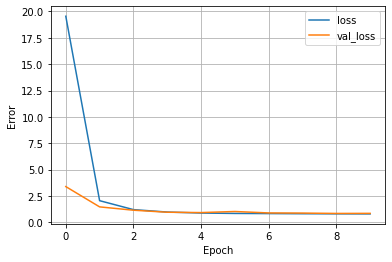

processing fold # 1
107/107 [==============================] - 0s 1ms/step - loss: 0.7282 - mae: 0.4761 - mse: 0.7282


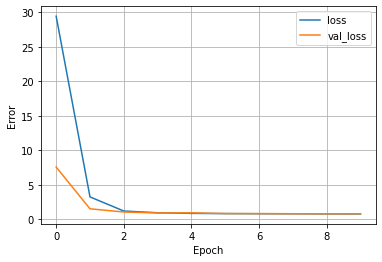

processing fold # 2
107/107 [==============================] - 0s 1ms/step - loss: 0.8571 - mae: 0.5017 - mse: 0.8571


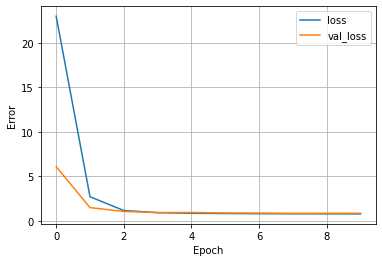

processing fold # 3
107/107 [==============================] - 0s 1ms/step - loss: 0.7788 - mae: 0.4953 - mse: 0.7788


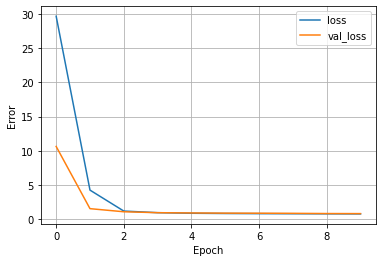

107/107 [==============================] - 0s 1ms/step


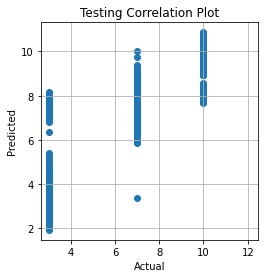

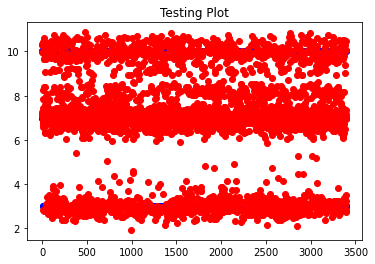

425/425 [==============================] - 0s 1ms/step


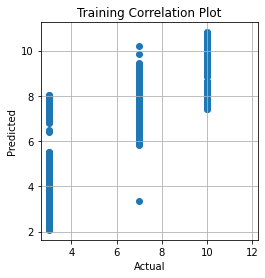

first hidden layer 33
second hidden layer 34
processing fold # 0
107/107 [==============================] - 0s 1ms/step - loss: 0.7884 - mae: 0.4924 - mse: 0.7884


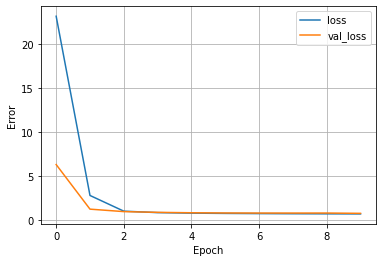

processing fold # 1
107/107 [==============================] - 0s 1ms/step - loss: 0.7402 - mae: 0.5040 - mse: 0.7402


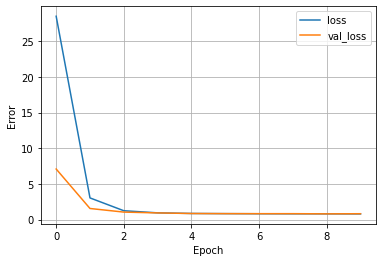

processing fold # 2
107/107 [==============================] - 0s 1ms/step - loss: 0.8132 - mae: 0.5312 - mse: 0.8132


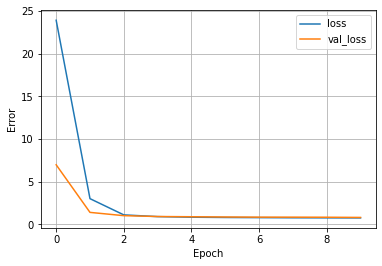

processing fold # 3
107/107 [==============================] - 0s 1ms/step - loss: 0.8065 - mae: 0.5045 - mse: 0.8065


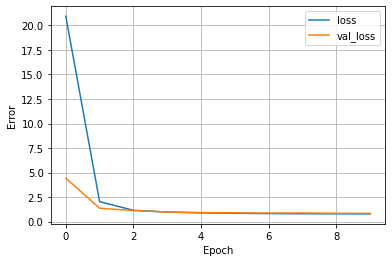

107/107 [==============================] - 0s 972us/step


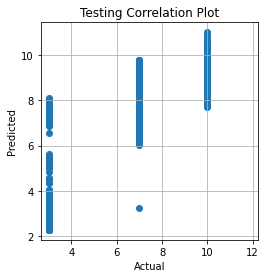

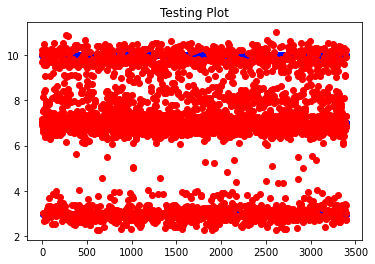

425/425 [==============================] - 1s 1ms/step


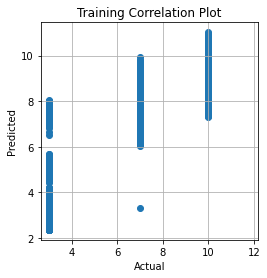

first hidden layer 33
second hidden layer 35
processing fold # 0
107/107 [==============================] - 0s 1ms/step - loss: 0.8351 - mae: 0.5362 - mse: 0.8351


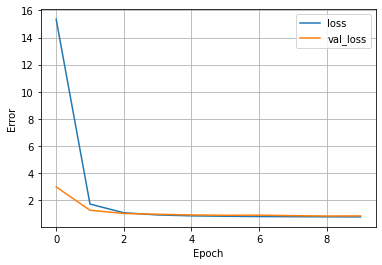

processing fold # 1
107/107 [==============================] - 0s 1ms/step - loss: 0.7402 - mae: 0.4911 - mse: 0.7402


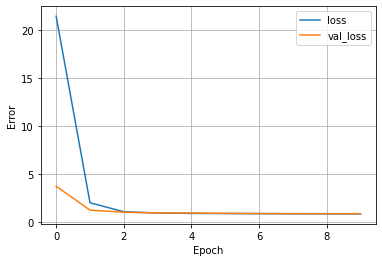

processing fold # 2
107/107 [==============================] - 0s 1ms/step - loss: 0.8130 - mae: 0.5132 - mse: 0.8130


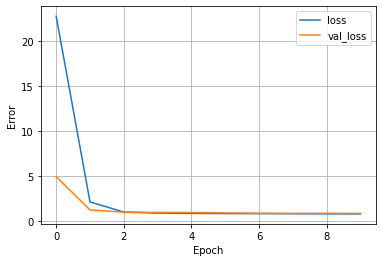

processing fold # 3
107/107 [==============================] - 0s 1ms/step - loss: 0.8286 - mae: 0.4942 - mse: 0.8286


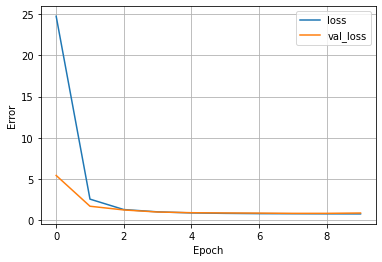

107/107 [==============================] - 0s 1ms/step


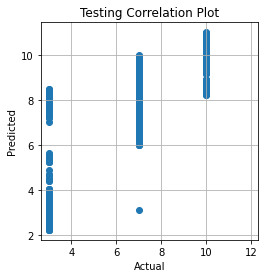

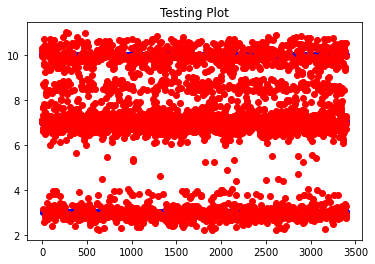

425/425 [==============================] - 0s 1ms/step


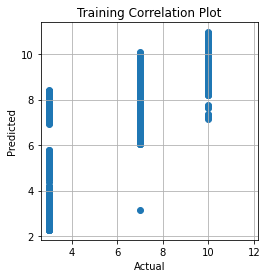

first hidden layer 33
second hidden layer 36
processing fold # 0
107/107 [==============================] - 0s 1ms/step - loss: 0.8353 - mae: 0.5150 - mse: 0.8353


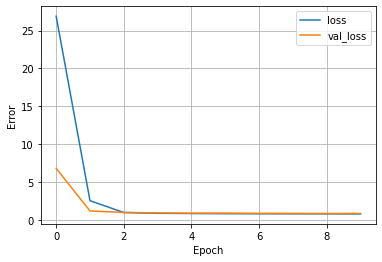

processing fold # 1
107/107 [==============================] - 0s 1ms/step - loss: 0.7402 - mae: 0.5121 - mse: 0.7402


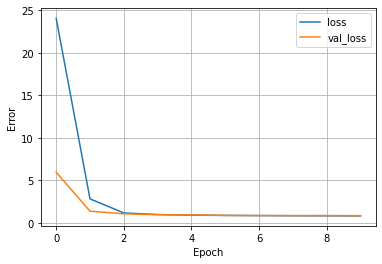

processing fold # 2
107/107 [==============================] - 0s 1ms/step - loss: 0.8115 - mae: 0.4875 - mse: 0.8115


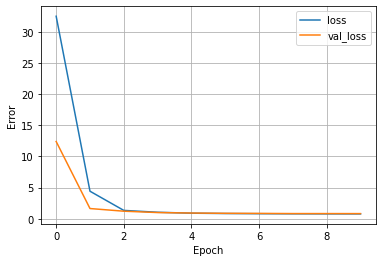

processing fold # 3
107/107 [==============================] - 0s 1ms/step - loss: 0.8381 - mae: 0.5716 - mse: 0.8381


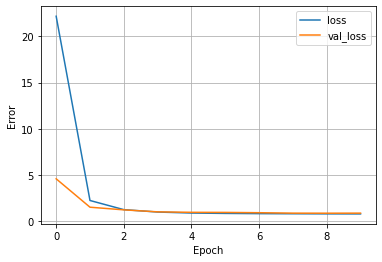

107/107 [==============================] - 0s 1ms/step


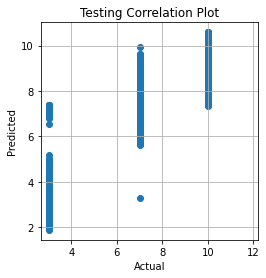

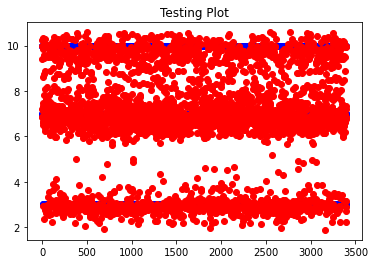

425/425 [==============================] - 0s 1ms/step


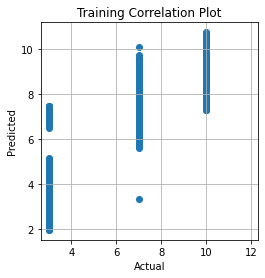

first hidden layer 33
second hidden layer 37
processing fold # 0
107/107 [==============================] - 0s 1ms/step - loss: 0.8276 - mae: 0.5071 - mse: 0.8276


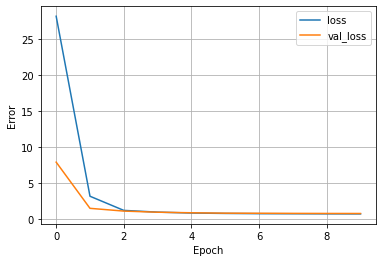

processing fold # 1
107/107 [==============================] - 0s 1ms/step - loss: 0.7474 - mae: 0.5083 - mse: 0.7474


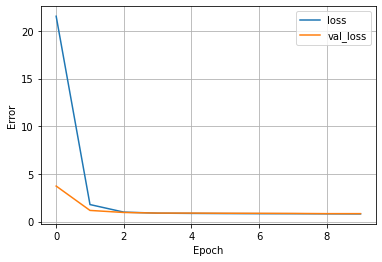

processing fold # 2
107/107 [==============================] - 0s 1ms/step - loss: 0.8261 - mae: 0.5122 - mse: 0.8261


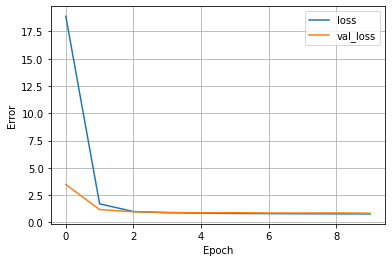

processing fold # 3
107/107 [==============================] - 0s 1ms/step - loss: 0.8101 - mae: 0.5080 - mse: 0.8101


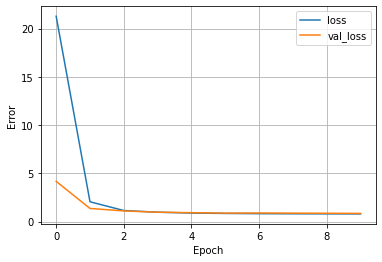

107/107 [==============================] - 0s 916us/step


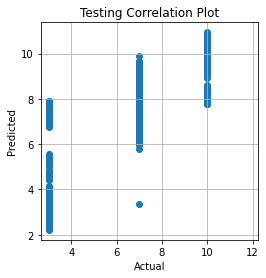

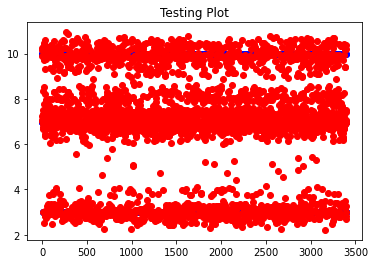

425/425 [==============================] - 0s 974us/step


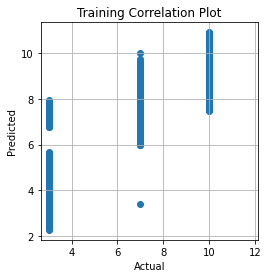

first hidden layer 34
second hidden layer 32
processing fold # 0
107/107 [==============================] - 0s 1ms/step - loss: 0.8325 - mae: 0.4982 - mse: 0.8325


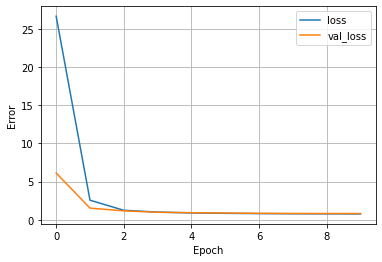

processing fold # 1
107/107 [==============================] - 0s 1ms/step - loss: 0.7389 - mae: 0.4875 - mse: 0.7389


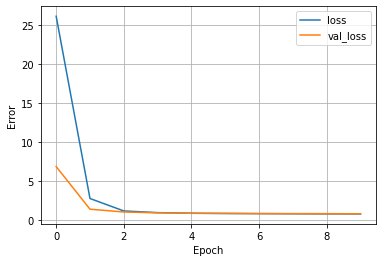

processing fold # 2
107/107 [==============================] - 0s 1ms/step - loss: 0.8347 - mae: 0.4905 - mse: 0.8347


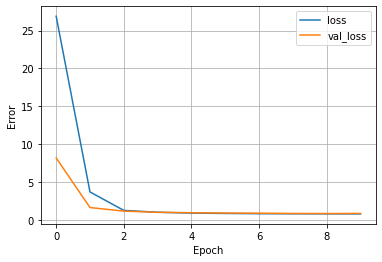

processing fold # 3
107/107 [==============================] - 0s 1ms/step - loss: 0.8083 - mae: 0.5049 - mse: 0.8083


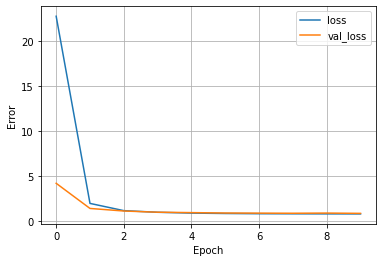

107/107 [==============================] - 0s 1ms/step


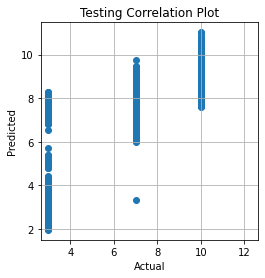

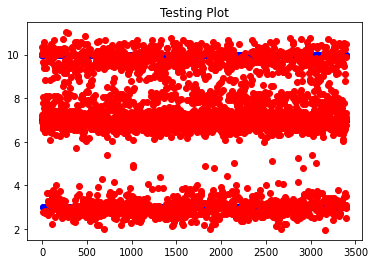

425/425 [==============================] - 0s 1ms/step


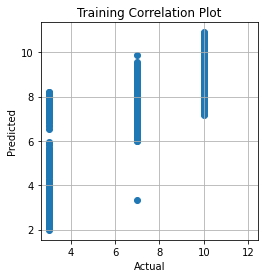

first hidden layer 34
second hidden layer 33
processing fold # 0
107/107 [==============================] - 0s 1ms/step - loss: 0.8143 - mae: 0.5002 - mse: 0.8143


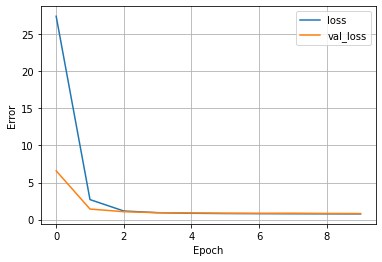

processing fold # 1
107/107 [==============================] - 0s 1ms/step - loss: 0.7609 - mae: 0.5156 - mse: 0.7609


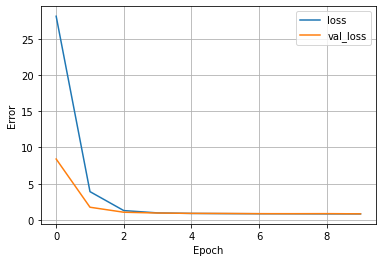

processing fold # 2
107/107 [==============================] - 0s 1ms/step - loss: 0.8377 - mae: 0.4993 - mse: 0.8377


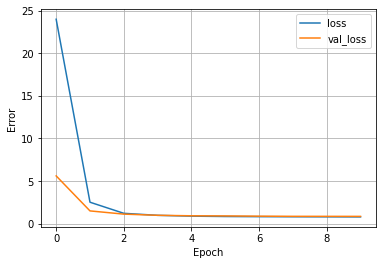

processing fold # 3
107/107 [==============================] - 0s 1ms/step - loss: 0.8125 - mae: 0.5236 - mse: 0.8125


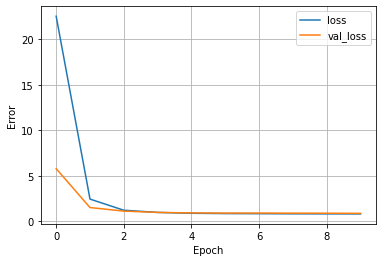

107/107 [==============================] - 0s 1ms/step


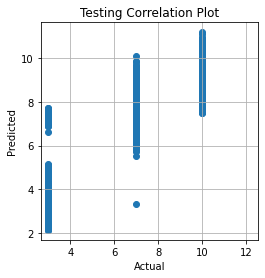

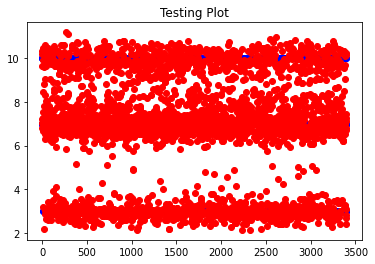

425/425 [==============================] - 0s 999us/step


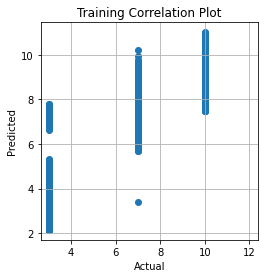

first hidden layer 34
second hidden layer 34
processing fold # 0
107/107 [==============================] - 0s 1ms/step - loss: 0.8577 - mae: 0.5595 - mse: 0.8577


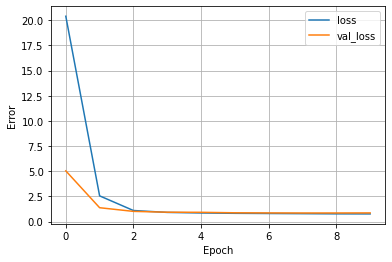

processing fold # 1
107/107 [==============================] - 0s 1ms/step - loss: 0.7336 - mae: 0.5024 - mse: 0.7336


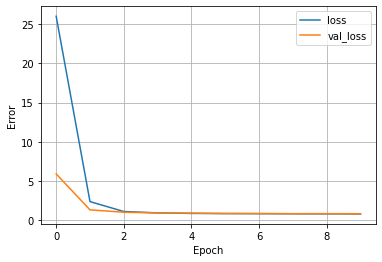

processing fold # 2
107/107 [==============================] - 0s 1ms/step - loss: 0.8244 - mae: 0.5364 - mse: 0.8244


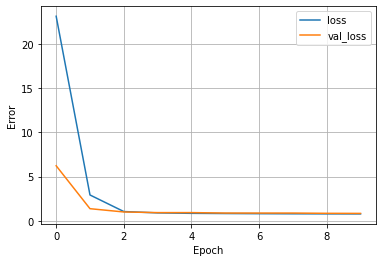

processing fold # 3
107/107 [==============================] - 0s 1ms/step - loss: 0.7977 - mae: 0.5217 - mse: 0.7977


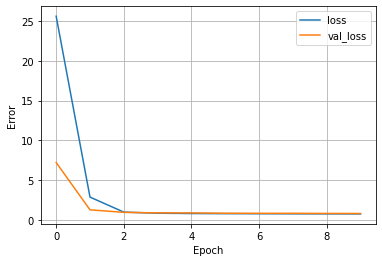

107/107 [==============================] - 0s 1ms/step


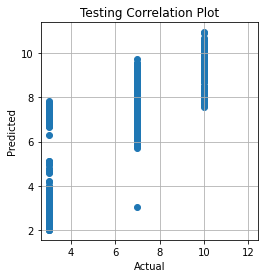

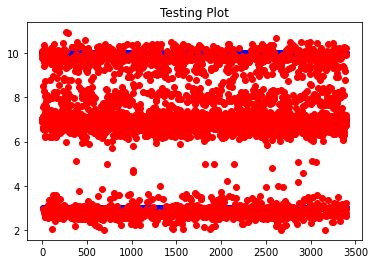

425/425 [==============================] - 0s 1ms/step


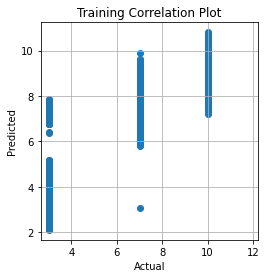

first hidden layer 34
second hidden layer 35
processing fold # 0
107/107 [==============================] - 0s 1ms/step - loss: 0.8299 - mae: 0.5183 - mse: 0.8299


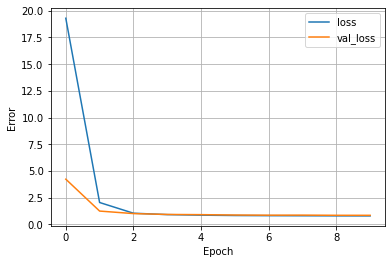

processing fold # 1
107/107 [==============================] - 0s 1ms/step - loss: 0.7308 - mae: 0.4951 - mse: 0.7308


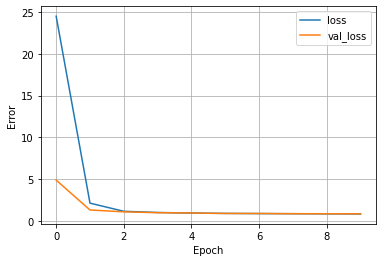

processing fold # 2
107/107 [==============================] - 0s 1ms/step - loss: 0.8292 - mae: 0.5075 - mse: 0.8292


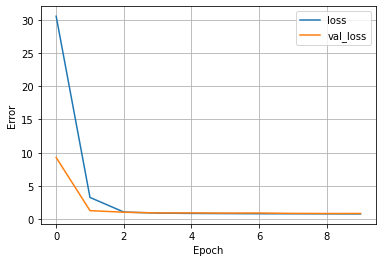

processing fold # 3
107/107 [==============================] - 0s 1ms/step - loss: 0.8305 - mae: 0.5484 - mse: 0.8305


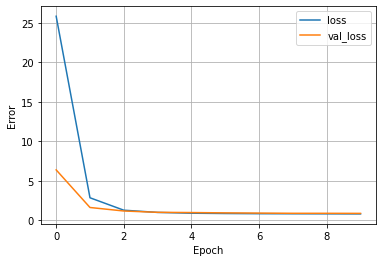

107/107 [==============================] - 0s 1ms/step


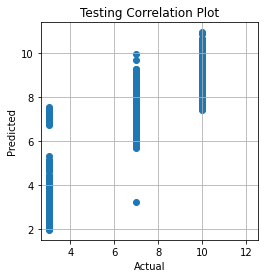

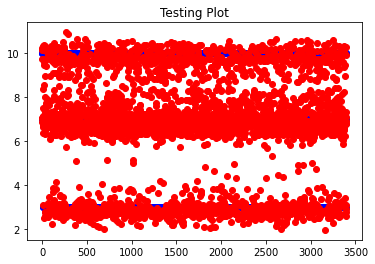

425/425 [==============================] - 0s 1ms/step


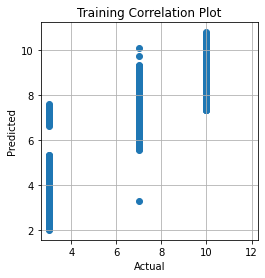

first hidden layer 34
second hidden layer 36
processing fold # 0
107/107 [==============================] - 0s 1ms/step - loss: 0.8034 - mae: 0.5036 - mse: 0.8034


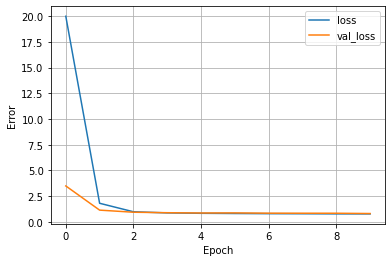

processing fold # 1
107/107 [==============================] - 0s 1ms/step - loss: 0.7173 - mae: 0.4597 - mse: 0.7173


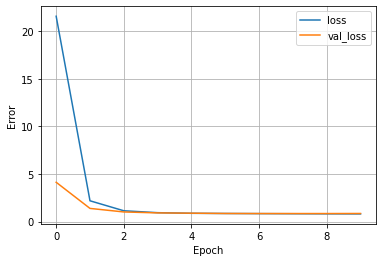

processing fold # 2
107/107 [==============================] - 0s 1ms/step - loss: 0.7993 - mae: 0.4913 - mse: 0.7993


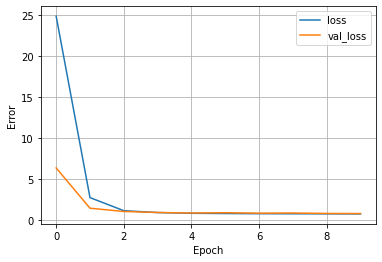

processing fold # 3
107/107 [==============================] - 0s 1ms/step - loss: 0.8135 - mae: 0.5033 - mse: 0.8135


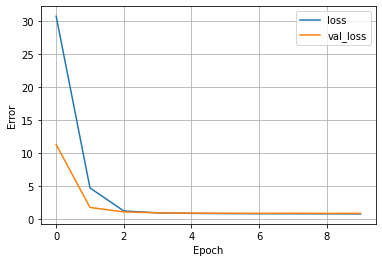

107/107 [==============================] - 0s 1ms/step


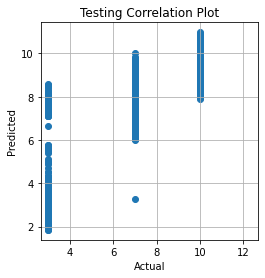

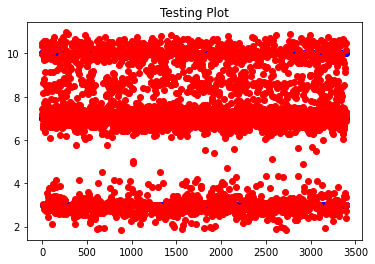

425/425 [==============================] - 0s 1ms/step


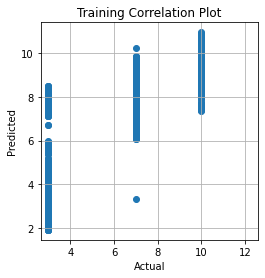

first hidden layer 35
second hidden layer 32
processing fold # 0
107/107 [==============================] - 0s 1ms/step - loss: 0.8459 - mae: 0.5695 - mse: 0.8459


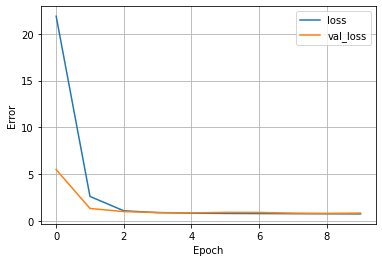

processing fold # 1
107/107 [==============================] - 0s 1ms/step - loss: 0.7978 - mae: 0.5543 - mse: 0.7978


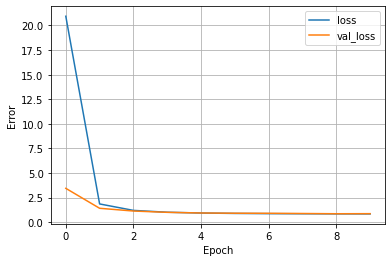

processing fold # 2
107/107 [==============================] - 0s 1ms/step - loss: 0.8460 - mae: 0.4948 - mse: 0.8460


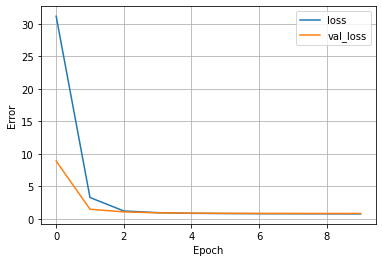

processing fold # 3
107/107 [==============================] - 0s 1ms/step - loss: 0.8036 - mae: 0.5077 - mse: 0.8036


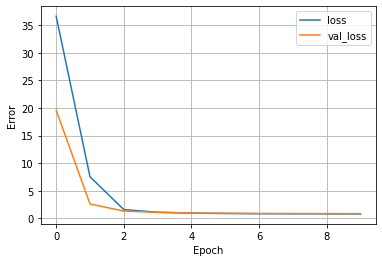

107/107 [==============================] - 0s 1ms/step


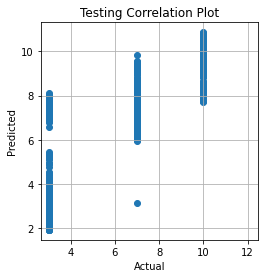

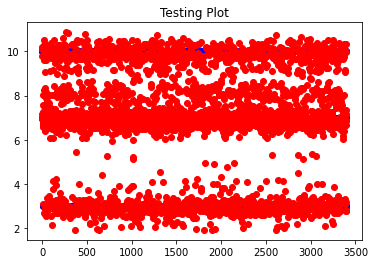

425/425 [==============================] - 0s 1ms/step


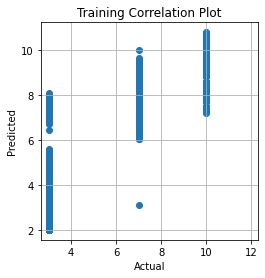

first hidden layer 35
second hidden layer 33
processing fold # 0
107/107 [==============================] - 0s 1ms/step - loss: 0.8381 - mae: 0.5313 - mse: 0.8381


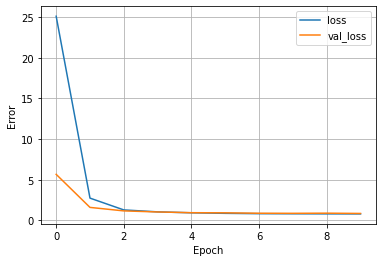

processing fold # 1
107/107 [==============================] - 0s 1ms/step - loss: 0.7374 - mae: 0.5038 - mse: 0.7374


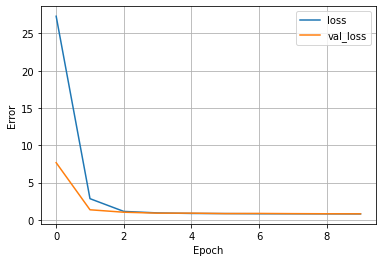

processing fold # 2
107/107 [==============================] - 0s 1ms/step - loss: 0.8173 - mae: 0.5048 - mse: 0.8173


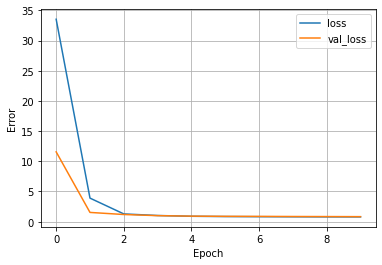

processing fold # 3
107/107 [==============================] - 0s 1ms/step - loss: 0.8446 - mae: 0.5281 - mse: 0.8446


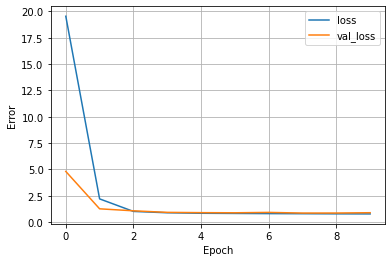

107/107 [==============================] - 0s 1ms/step


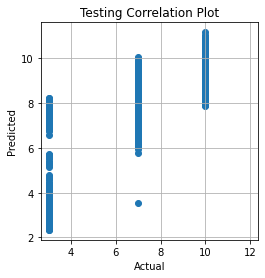

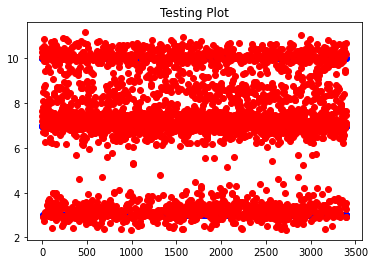

425/425 [==============================] - 0s 1ms/step


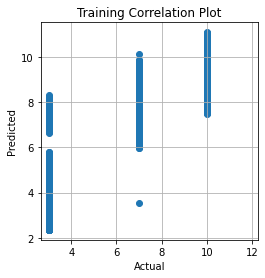

first hidden layer 35
second hidden layer 34
processing fold # 0
107/107 [==============================] - 0s 1ms/step - loss: 0.8104 - mae: 0.4891 - mse: 0.8104


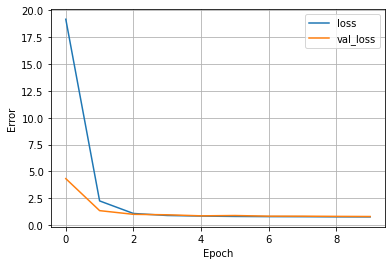

processing fold # 1
107/107 [==============================] - 0s 1ms/step - loss: 0.7233 - mae: 0.4889 - mse: 0.7233


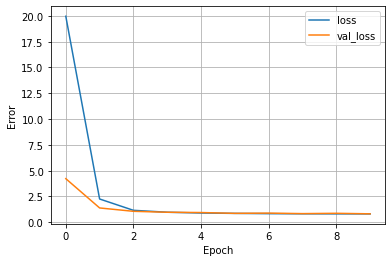

processing fold # 2
107/107 [==============================] - 0s 1ms/step - loss: 0.8245 - mae: 0.5196 - mse: 0.8245


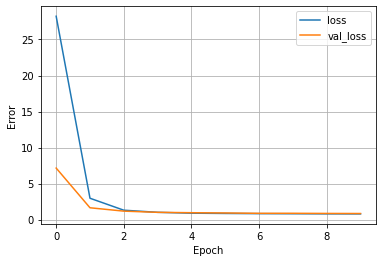

processing fold # 3
107/107 [==============================] - 0s 1ms/step - loss: 0.8181 - mae: 0.5396 - mse: 0.8181


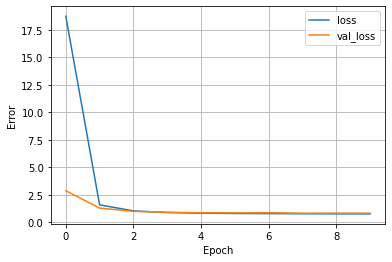

107/107 [==============================] - 0s 1ms/step


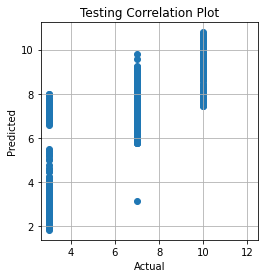

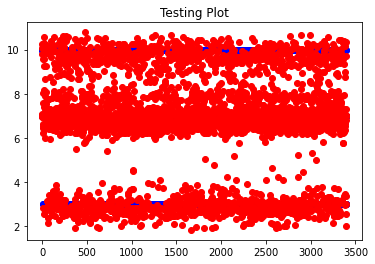

425/425 [==============================] - 1s 1ms/step


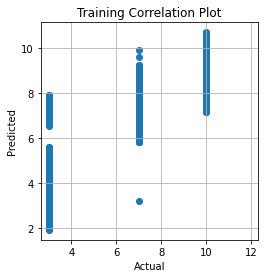

first hidden layer 35
second hidden layer 35
processing fold # 0
107/107 [==============================] - 0s 1ms/step - loss: 0.8580 - mae: 0.5002 - mse: 0.8580


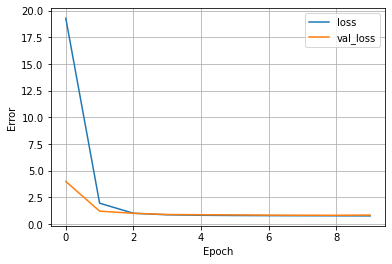

processing fold # 1
107/107 [==============================] - 0s 1ms/step - loss: 0.7563 - mae: 0.5201 - mse: 0.7563


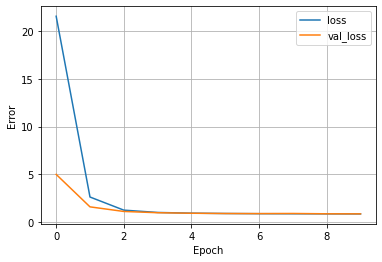

processing fold # 2
107/107 [==============================] - 0s 1ms/step - loss: 0.7996 - mae: 0.4976 - mse: 0.7996


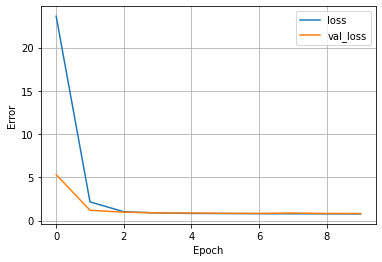

processing fold # 3
107/107 [==============================] - 0s 1ms/step - loss: 0.8045 - mae: 0.5029 - mse: 0.8045


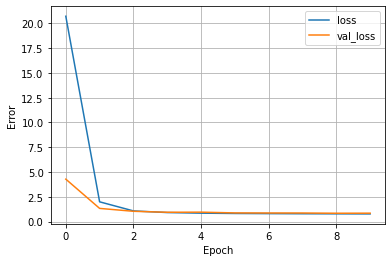

107/107 [==============================] - 0s 1ms/step


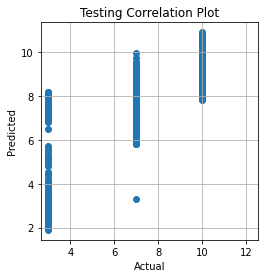

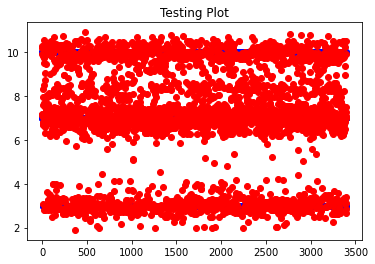

425/425 [==============================] - 0s 1ms/step


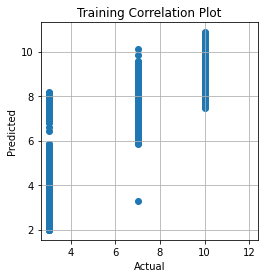

first hidden layer 36
second hidden layer 32
processing fold # 0
107/107 [==============================] - 0s 1ms/step - loss: 0.8228 - mae: 0.4889 - mse: 0.8228


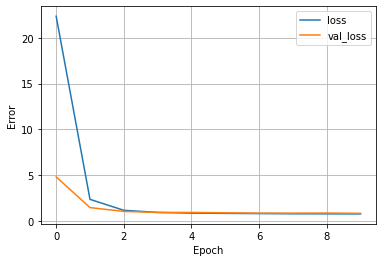

processing fold # 1
107/107 [==============================] - 0s 1ms/step - loss: 0.7752 - mae: 0.5179 - mse: 0.7752


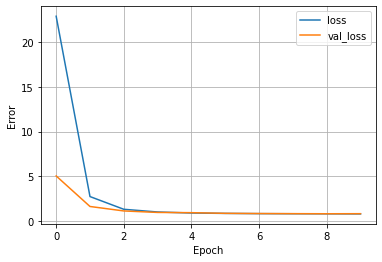

processing fold # 2
107/107 [==============================] - 0s 1ms/step - loss: 0.8222 - mae: 0.5261 - mse: 0.8222


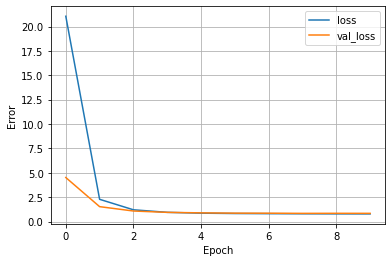

processing fold # 3
107/107 [==============================] - 0s 1ms/step - loss: 0.7954 - mae: 0.4944 - mse: 0.7954


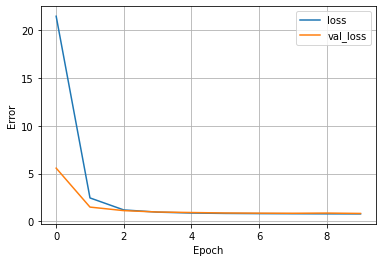

107/107 [==============================] - 0s 1ms/step


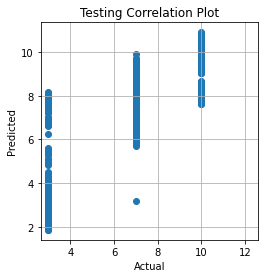

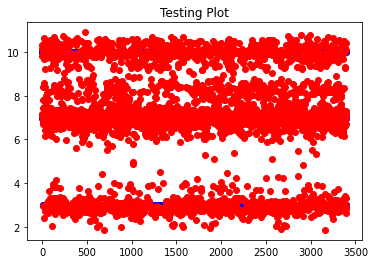

425/425 [==============================] - 0s 1ms/step


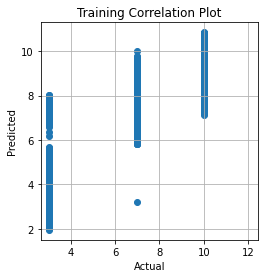

first hidden layer 36
second hidden layer 33
processing fold # 0
107/107 [==============================] - 0s 1ms/step - loss: 0.8031 - mae: 0.4782 - mse: 0.8031


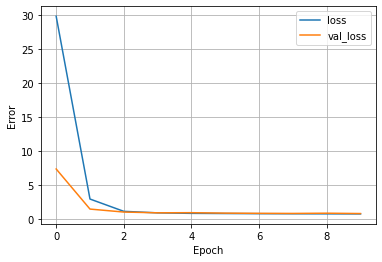

processing fold # 1
107/107 [==============================] - 0s 1ms/step - loss: 0.7293 - mae: 0.4862 - mse: 0.7293


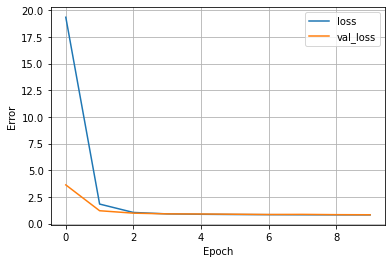

processing fold # 2
107/107 [==============================] - 0s 1ms/step - loss: 0.8288 - mae: 0.4850 - mse: 0.8288


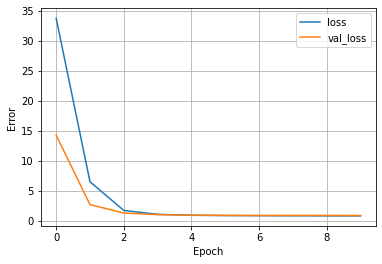

processing fold # 3
107/107 [==============================] - 0s 1ms/step - loss: 0.8592 - mae: 0.5092 - mse: 0.8592


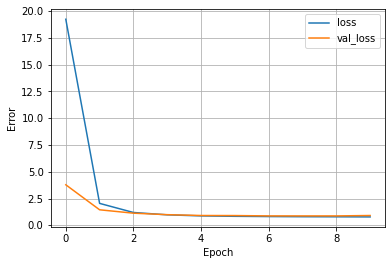

107/107 [==============================] - 0s 1ms/step


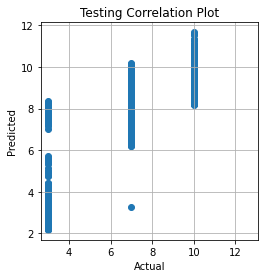

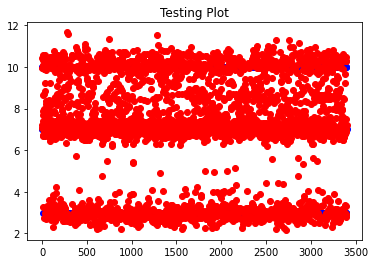

425/425 [==============================] - 0s 1ms/step


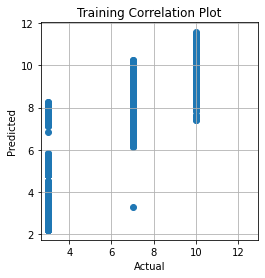

first hidden layer 36
second hidden layer 34
processing fold # 0
107/107 [==============================] - 0s 1ms/step - loss: 0.8243 - mae: 0.5194 - mse: 0.8243


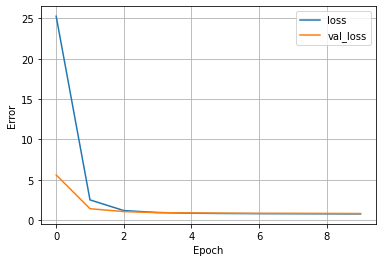

processing fold # 1
107/107 [==============================] - 0s 1ms/step - loss: 0.7126 - mae: 0.4846 - mse: 0.7126


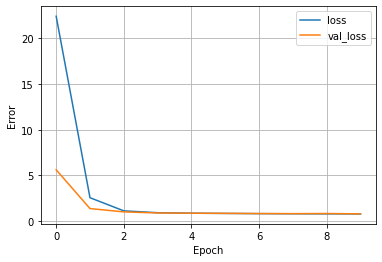

processing fold # 2
107/107 [==============================] - 0s 1ms/step - loss: 0.8511 - mae: 0.5043 - mse: 0.8511


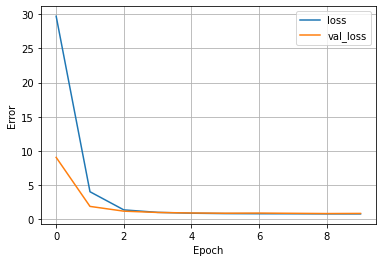

processing fold # 3
107/107 [==============================] - 0s 1ms/step - loss: 0.8270 - mae: 0.4982 - mse: 0.8270


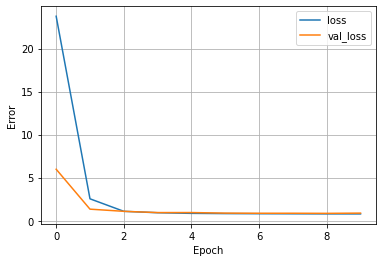

107/107 [==============================] - 0s 1ms/step


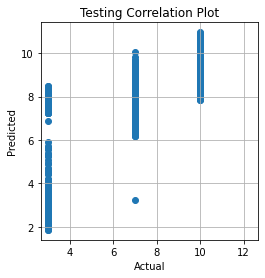

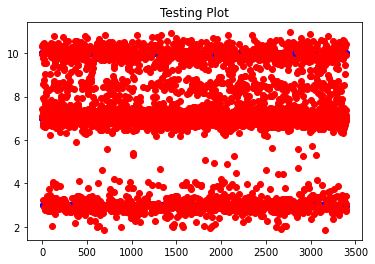

425/425 [==============================] - 1s 1ms/step


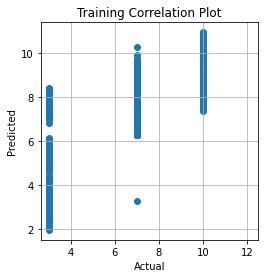

first hidden layer 37
second hidden layer 32
processing fold # 0
107/107 [==============================] - 0s 1ms/step - loss: 0.8245 - mae: 0.5246 - mse: 0.8245


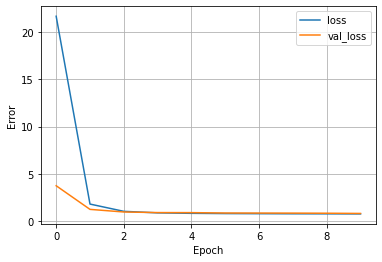

processing fold # 1
107/107 [==============================] - 0s 1ms/step - loss: 0.7262 - mae: 0.4793 - mse: 0.7262


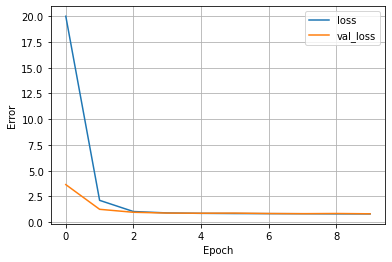

processing fold # 2
107/107 [==============================] - 0s 1ms/step - loss: 0.8175 - mae: 0.5123 - mse: 0.8175


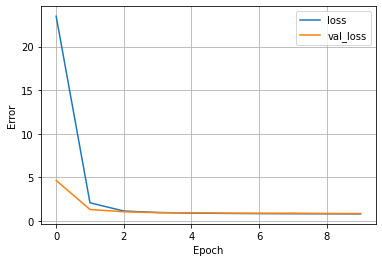

processing fold # 3
107/107 [==============================] - 0s 1ms/step - loss: 0.7799 - mae: 0.4805 - mse: 0.7799


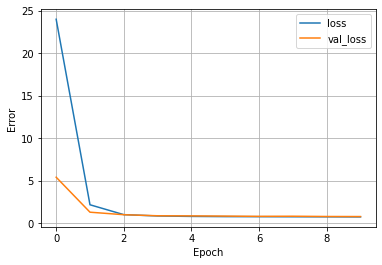

107/107 [==============================] - 0s 1ms/step


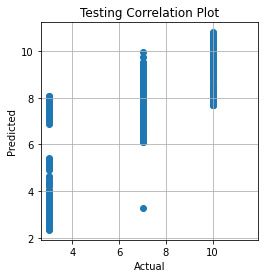

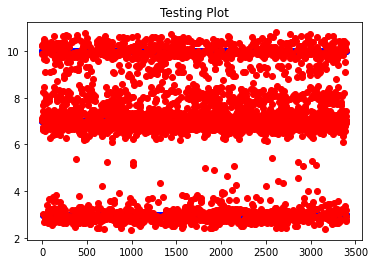

425/425 [==============================] - 0s 1ms/step


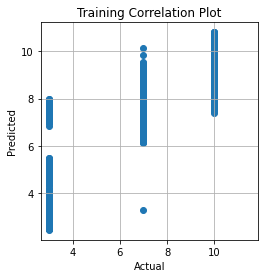

first hidden layer 37
second hidden layer 33
processing fold # 0
107/107 [==============================] - 0s 1ms/step - loss: 0.8291 - mae: 0.5328 - mse: 0.8291


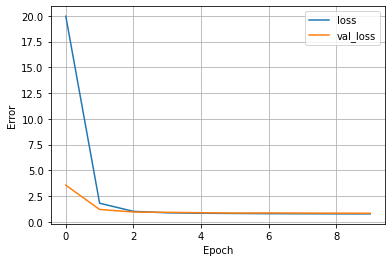

processing fold # 1
107/107 [==============================] - 0s 1ms/step - loss: 0.7722 - mae: 0.5237 - mse: 0.7722


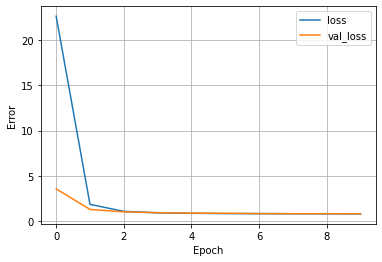

processing fold # 2
107/107 [==============================] - 0s 1ms/step - loss: 0.8097 - mae: 0.4885 - mse: 0.8097


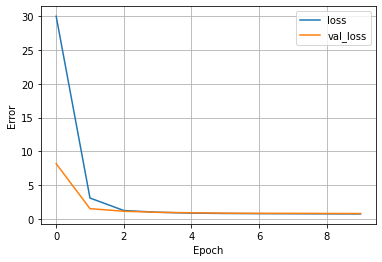

processing fold # 3
107/107 [==============================] - 0s 1ms/step - loss: 0.7796 - mae: 0.4863 - mse: 0.7796


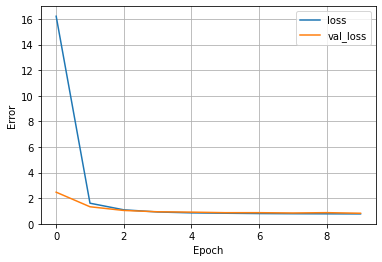

107/107 [==============================] - 0s 1ms/step


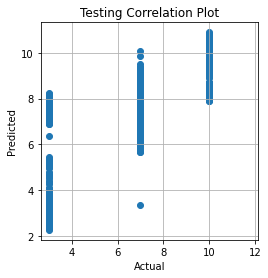

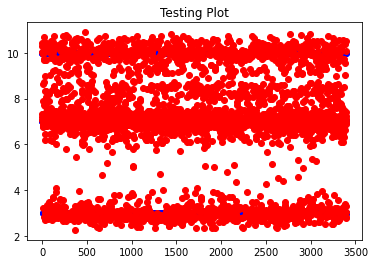

425/425 [==============================] - 1s 1ms/step


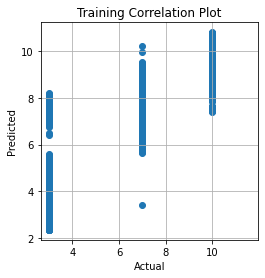

first hidden layer 38
second hidden layer 32
processing fold # 0
107/107 [==============================] - 0s 1ms/step - loss: 0.8333 - mae: 0.5292 - mse: 0.8333


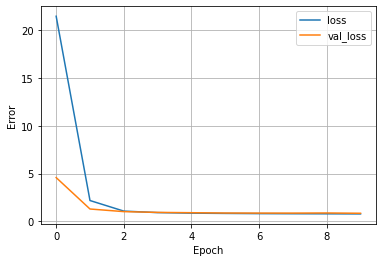

processing fold # 1
107/107 [==============================] - 0s 1ms/step - loss: 0.7264 - mae: 0.4701 - mse: 0.7264


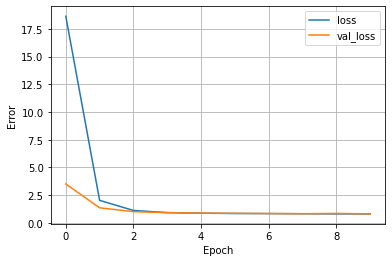

processing fold # 2
107/107 [==============================] - 0s 1ms/step - loss: 0.8296 - mae: 0.5452 - mse: 0.8296


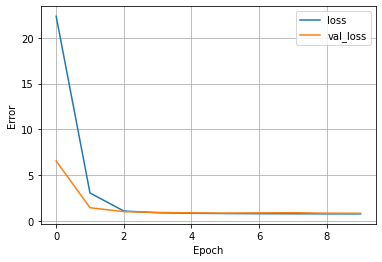

processing fold # 3
107/107 [==============================] - 0s 1ms/step - loss: 0.8267 - mae: 0.5130 - mse: 0.8267


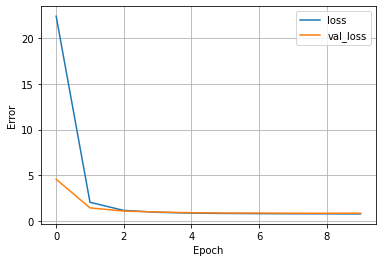

107/107 [==============================] - 0s 1ms/step


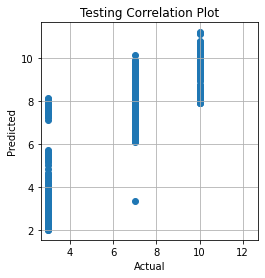

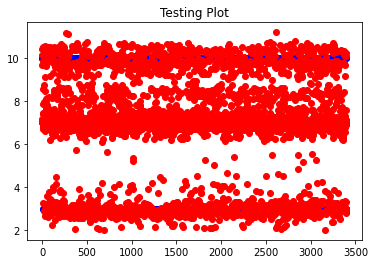

425/425 [==============================] - 1s 1ms/step


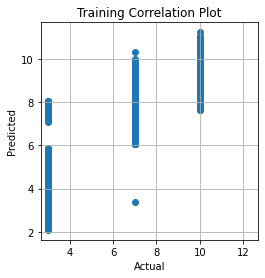

In [14]:
def KCrossValidation(i, features, labels, num_val_samples, epochs, batch, verbose, n1, n2):

    print('processing fold #', i)
    val_data = features[i * num_val_samples: (i + 1) * num_val_samples]
    val_targets = labels[i * num_val_samples: (i + 1) * num_val_samples]

    partial_train_data = np.concatenate([features[:i * num_val_samples], features[(i + 1) * num_val_samples:]], axis=0)
    partial_train_targets = np.concatenate(     [labels[:i * num_val_samples], labels[(i + 1) * num_val_samples:]],     axis=0)

    model = build_model(n1, n2)

    history = model_history(partial_train_data, partial_train_targets, model, epochs, batch, verbose)

    test_loss, test_mae, test_mse = model.evaluate(val_data, val_targets, verbose=1)

    return model, history, test_loss, test_mae, test_mse

import numpy as np
k = 4
num_val_samples = len(train_labels) // k

sum_nodes = 70
num_epochs = 10
batch_size = 100
verbose = 0
avg_val_scores = []
order_of_architecture = []

all_networks  = []
all_history  = []
mae_history = []



#(TAKEN FROM DEEP LEARNING WITH PYTHON BY MANNING)
for i in range(32, sum_nodes):

    for j in range(32, sum_nodes):
        if (i+j > sum_nodes):
            continue
        
        print("first hidden layer", i)
        print("second hidden layer", j)
        k_fold_test_scores = []
        k_models = []
        k_history = []

        k_mae_history = []

        for fold in range(k):
            model, history, test_loss, test_mae, test_mse = KCrossValidation(
                fold, 
                train_features, 
                train_labels, 
                num_val_samples, 
                num_epochs, 
                batch_size, 
                verbose, 
                j, 
                i)

            plot_loss(history)
            k_fold_test_scores.append(test_mae)
            k_history.append(history)
            k_models.append(model)
            k_mae_history.append(history['val_mae'])


        avg_val_scores.append(sum(k_fold_test_scores)/len(k_fold_test_scores))
        all_history.append(k_history)
        all_networks.append(k_models)

        
        mae_history.append([ np.mean([x[i] for x in k_mae_history]) for i in range(num_epochs)])


        order_of_architecture.append([i, j])


        test_predictions = correlation_plots(model, test_labels, test_features, "Testing Correlation Plot", "Actual", "Predicted")
        plotGraph(test_labels, test_predictions, "Testing Plot")


        training_predictions = correlation_plots(model, train_labels, train_features, "Training Correlation Plot", "Actual", "Predicted")
        #plotGraph(train_labels, training_predictions, "Training Plot")


# CREATE 3D MODELS OF THE VARIOUS PARAMETERS

In [ ]:
#from modulefinder import IMPORT_NAME
#import os.path
#if os.path.isfile('models title.h5') is False:
 #   model.save('models title.h5')

#Import#
#from tensorflow.keras.models import load_model
#new_model = load_model('models title.h5')

#print(new_model.to_json())